
# Week 3 — Day 1   
**Θέμα:** Binary Classification (Logistic Regression) + Regularization + Metrics

**Στόχοι notebook**
- Baseline `LogisticRegression` σε 70/30 split με `stratify`
- Pipeline: `StandardScaler` → `LogisticRegression(class_weight="balanced")`
- Μετρικές: Accuracy, Precision, Recall, F1, **ROC-AUC**, **Average Precision (PR-AUC)**
- Καμπύλες ROC & Precision–Recall + Confusion Matrix


Τι σημαίνουν οι στόχοι & οι επιλογές
1) 70/30 split με stratify

Γιατί: Στα credit card fraud datasets η κλάση είναι πολύ ανισόρροπη (fraud ≪ non-fraud).

stratify=y στο train_test_split διατηρεί την ίδια αναλογία θετικών/αρνητικών κλάσεων και στα δύο σύνολα, ώστε το test να είναι αντιπροσωπευτικό.

2) Pipeline: StandardScaler → LogisticRegression(class_weight="balanced")

StandardScaler: Η λογιστική παλινδρόμηση είναι γραμμικό μοντέλο με regularization· η κλίμακα των features επηρεάζει πολύ την εκπαίδευση. Η κανονικοποίηση (0 μέση τιμή, 1 διασπορά) κάνει το optimization σταθερό και πιο γρήγορο.

class_weight="balanced": Αυτόματα δίνει μεγαλύτερο βάρος στη σπάνια κλάση (fraud), ώστε να μην την “αγνοεί” το μοντέλο για να κερδίσει σε accuracy. Πολύ χρήσιμο σε imbalanced datasets.

Pipeline: Εξασφαλίζει ότι η κανονικοποίηση εφαρμόζεται μόνο στο train (fit) και επαναχρησιμοποιείται σωστά στο test (transform) χωρίς data leakage, και ότι όλα γίνονται με ένα fit/predict.

3) Μετρικές: Accuracy, Precision, Recall, F1, ROC-AUC, Average Precision (PR-AUC)

Accuracy: % σωστών προβλέψεων. Σε ανισόρροπα δεδομένα μπορεί να είναι παραπλανητικό (π.χ. 99.8% λέγοντας “όλα μη-fraud”).

Precision: Από όσα προέβλεψα ως fraud, πόσα ήταν όντως fraud; (focus στα false positives)

Recall (Sensitivity/TPR): Από όλα τα πραγματικά fraud, πόσα τα βρήκα; (focus στα false negatives).
Για fraud detection, συχνά δίνουμε προτεραιότητα στο recall (να μην μας ξεφύγουν).

F1: Ισορροπεί precision & recall (αρμονικός μέσος).

ROC-AUC: Περιοχή κάτω από την καμπύλη ROC (TPR vs FPR) για όλα τα thresholds.

Average Precision (PR-AUC): Περιοχή κάτω από την καμπύλη Precision–Recall.
Σε πολύ ανισόρροπες κλάσεις, το PR-AUC είναι συνήθως πιο κατατοπιστικό από το ROC-AUC.

4) Καμπύλες ROC & Precision–Recall + Confusion Matrix

ROC curve: Δείχνει trade-off TPR vs FPR σε όλα τα thresholds.

PR curve: Trade-off Precision vs Recall· πιο “ειλικρινής” όταν το θετικό είναι σπάνιο.

Confusion Matrix: Πίνακας TP/FP/FN/TN στο default threshold (συνήθως 0.5).
Για παραγωγή, συχνά ρυθμίζουμε το threshold ανά στόχο (π.χ. maximize recall με ανεκτό FP rate).

Γιατί αυτά τα imports

RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay: σου γλιτώνουν boilerplate κώδικα—παίρνουν estimator ή προβλέψεις και φτιάχνουν έτοιμα, σωστά labels & axes.

average_precision_score: δίνει AP (το “PR-AUC”). Δεν είναι απλώς η αριθμητική ολοκλήρωση της καμπύλης, είναι ειδικός ορισμός με precision ως συνάρτηση του recall.

In [1]:

# -------------------- Imports --------------------
from pathlib import Path                 # Διαχείριση διαδρομών αρχείων (cross-platform)
import pandas as pd                      # Διαχείριση/ανάλυση δεδομένων (DataFrame)
import numpy as np                       # Αριθμητικές πράξεις, arrays, βοηθητικά
import matplotlib.pyplot as plt          # Γραφήματα / οπτικοποίηση

from sklearn.model_selection import train_test_split   # Train/test split (με stratify)
from sklearn.preprocessing import StandardScaler       # Κανονικοποίηση χαρακτηριστικών (0-mean, unit-variance)
from sklearn.pipeline import make_pipeline             # Δημιουργία pipeline (Scaler → Model) με 1 γραμμή
from sklearn.linear_model import LogisticRegression    # Γραμμικό μοντέλο ταξινόμησης με L2 regularization by default
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,     # Βασικές μετρικές
    roc_auc_score, average_precision_score,                      # Περιοχές καμπυλών ROC/PR (AUC & AP)
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay  # Έτοιμες κλάσεις για plots
)

# -------------------- Inline plots --------------------
%matplotlib inline
# Jupyter magic: τα plots εμφανίζονται μέσα στο notebook output, κάτω από το κελί


In [ ]:
# -------------------- Paths & configuration --------------------

# Ορίζουμε το path προς το dataset (CSV αρχείο).
# Το ../ σημαίνει "πήγαινε 1 φάκελο πίσω" (σχετική διαδρομή από το notebook).
DATA_PATH = Path("../data/data_raw/creditcard.csv")

# Φάκελος για αποθήκευση εικόνων (ROC/PR curves, confusion matrix κτλ.)
IMAGES_DIR = Path("../images/week3")

# Φάκελος για αποθήκευση reports (π.χ. μετρικές σε CSV ή JSON).
REPORTS_DIR = Path("../reports")

# Δημιουργία των φακέλων (αν δεν υπάρχουν ήδη).
# parents=True -> φτιάχνει και ενδιάμεσους φακέλους αν χρειαστεί
# exist_ok=True -> δεν σκάει αν ο φάκελος υπάρχει ήδη
IMAGES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# Λίστα πιθανών ονομάτων για τη στήλη-στόχο (target variable).
# Σε διαφορετικά datasets μπορεί να λέγεται "Class", "class", "is_fraud" ή "fraud".
# Έτσι το notebook μπορεί να αναγνωρίσει αυτόματα ποια είναι η στήλη-στόχος.
CANDIDATE_TARGETS = ["Class", "class", "is_fraud", "fraud"]



In [6]:

# -------------------- Load dataset --------------------

# Έλεγχος αν υπάρχει το dataset στο καθορισμένο path
# Αν δεν υπάρχει, σταματάμε με FileNotFoundError και μήνυμα οδηγίας
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Λείπει το {DATA_PATH}. Βάλε το CSV στο data/data_raw/")

# Φορτώνουμε το dataset σε pandas DataFrame
df = pd.read_csv(DATA_PATH)

# Βρίσκουμε ποια στήλη είναι το target (μεταβλητή-στόχος).
# Ψάχνουμε στη λίστα CANDIDATE_TARGETS και επιστρέφουμε την πρώτη που υπάρχει.
target = next((c for c in CANDIDATE_TARGETS if c in df.columns), None)

# Αν δεν βρεθεί καμία από τις πιθανές στήλες, σηκώνουμε σφάλμα με καθαρό μήνυμα.
if target is None:
    raise ValueError(f"Δεν βρέθηκε target column. Δοκίμασε ένα από: {CANDIDATE_TARGETS}")

# Αφαιρούμε τυχόν διπλότυπες γραμμές για καθαρό dataset.
# reset_index(drop=True) -> ανανεώνει το index μετά την αφαίρεση.
df = df.drop_duplicates().reset_index(drop=True)

# Ορίζουμε y = target column (ετικέτες). 
# Το μετατρέπουμε σε int (0/1) για να είμαστε σίγουροι ότι είναι binary.
y = df[target].astype(int)

# Ορίζουμε X = όλα τα features εκτός από το target.
X = df.drop(columns=[target])

# Εκτυπώνουμε πληροφορίες για έλεγχο.
print(f"Target: {target}")   # Ποια στήλη χρησιμοποιείται ως στόχος
print("Shape:", df.shape)    # Διαστάσεις του dataset (γραμμές, στήλες)
print("Head:")               
display(df.head(3))          # Εμφάνιση των 3 πρώτων γραμμών με ωραία μορφή στο Jupyter
print("Positive rate:", y.mean())  # Ποσοστό θετικών περιπτώσεων (π.χ. fraud rate)



Target: Class
Shape: (283726, 31)
Head:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


Positive rate: 0.001667101358352777


In [7]:
# -------------------- Train / Test split --------------------

# Χωρίζουμε το dataset σε train (70%) και test (30%).
# - test_size=0.30 -> 30% για test set
# - stratify=y -> κρατάει την ίδια αναλογία κλάσεων (π.χ. fraud vs non-fraud) 
#   τόσο στο train όσο και στο test.
# - random_state=42 -> για αναπαραγωγιμότητα (ίδιο split κάθε φορά που τρέχουμε).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# Ελέγχουμε πόσα δείγματα πήγαν στο train/test (για επιβεβαίωση).
len(X_train), len(X_test)


(198608, 85118)

🔎 Γιατί είναι σημαντικό το stratify=y;

-Σε imbalanced datasets (όπως fraud detection), αν κάνεις split χωρίς stratify, υπάρχει κίνδυνος το test set να έχει ελάχιστα ή ακόμα και μηδενικά fraud cases.
-Με το stratify=y, διατηρείται η ίδια αναλογία θετικών/αρνητικών όπως στο αρχικό dataset. Έτσι:
-Το train set μαθαίνει σωστά και από τις δύο κλάσεις.
-Το test set είναι ρεαλιστικό και αντιπροσωπευτικό.

🔎 Γιατί random_state=42;

-Η τυχαιότητα στο split μπορεί να αλλάξει τα αποτελέσματα (ειδικά όταν η θετική κλάση είναι λίγη).
-Το random_state=42 “παγώνει” την τυχαιότητα → όποιος τρέξει το notebook (εσύ ή στο GitHub), παίρνει το ίδιο split.
-Το 42 είναι απλά μια “παράδοση” στην Python community, μπορεί να είναι οποιοδήποτε int.

In [8]:
# Έλεγχος ισορροπίας μετά το split
print("Train positive rate:", y_train.mean())
print("Test positive rate:", y_test.mean())

Train positive rate: 0.0016665995327479256
Test positive rate: 0.0016682722808336662


In [9]:
# -------------------- Pipeline: StandardScaler -> LogisticRegression --------------------

# Φτιάχνουμε ένα pipeline (σειρά βημάτων) που εκτελείται με μία κλήση fit/predict.
# Το pipeline έχει 2 στάδια:
# 1) StandardScaler: κανονικοποιεί κάθε feature (μέση τιμή = 0, τυπική απόκλιση = 1).
#    Αυτό είναι σημαντικό γιατί η LogisticRegression κάνει L2 regularization
#    και η κλίμακα των χαρακτηριστικών επηρεάζει το optimization.
# 2) LogisticRegression: μοντέλο γραμμικής ταξινόμησης με τις εξής παραμέτρους:
#    - class_weight="balanced": δίνει μεγαλύτερο βάρος στη σπάνια κλάση (fraud),
#      ώστε το μοντέλο να μην αγνοήσει τις λίγες θετικές περιπτώσεις.
#    - max_iter=1000: αυξάνει τον μέγιστο αριθμό επαναλήψεων στο optimization,
#      για να αποφύγουμε warnings "failed to converge".
#    - solver="lbfgs": ο αλγόριθμος optimization (γρήγορος και σταθερός για μεσαίου μεγέθους datasets).
#    - random_state=42: για αναπαραγωγιμότητα (ίδια αποτελέσματα σε κάθε εκτέλεση).
clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        solver="lbfgs",
        random_state=42
    )
)

# Εκπαιδεύουμε το pipeline στο training set.
# Το pipeline κάνει αυτόματα:
# - fit_transform(X_train) με το StandardScaler (μαθαίνει μέσους όρους και τυπ. αποκλίσεις από το train)
# - fit(...) με LogisticRegression χρησιμοποιώντας τα scaled δεδομένα.
clf.fit(X_train, y_train)



,steps,"[('standardscaler', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


🔎 Γιατί Pipeline και όχι ξεχωριστά;

Αν έκανες:

> scaler = StandardScaler()
> X_train_scaled = scaler.fit_transform(X_train)
> X_test_scaled = scaler.transform(X_test)

και μετά:

> logreg = LogisticRegression(...)
> logreg.fit(X_train_scaled, y_train)


θα έπρεπε χειροκίνητα να θυμάσαι σε κάθε στάδιο ποιο scaler έκανες fit.

Με το Pipeline:
- Όλα δένονται σε ένα αντικείμενο clf.
- Όταν καλείς clf.fit, εφαρμόζονται με σωστή σειρά.
- Όταν κάνεις clf.predict(X_test), το pipeline ξέρει να κάνει πρώτα scaler.transform και μετά predict.
- Έτσι αποφεύγεις data leakage και έχεις καθαρότερο κώδικα.

In [10]:

# -------------------- Predictions & probabilities --------------------

# Προβλέψεις (0 ή 1) στο test set με βάση το default threshold = 0.5.
y_pred = clf.predict(X_test)

# Πιθανότητες για την κλάση 1 (fraud).
# predict_proba επιστρέφει 2 στήλες: [prob(class=0), prob(class=1)].
# Με [:, 1] παίρνουμε τις πιθανότητες της θετικής κλάσης.
y_proba = clf.predict_proba(X_test)[:, 1]

# Υπολογισμός μετρικών από το test set
metrics = {
    # Accuracy: ποσοστό σωστών προβλέψεων (όχι πολύ χρήσιμο σε imbalanced data)
    "accuracy": accuracy_score(y_test, y_pred),
    
    # Precision: από όλα τα "fraud" που προέβλεψε το μοντέλο, πόσα ήταν όντως fraud;
    # zero_division=0: αν δεν υπάρξουν καθόλου θετικές προβλέψεις, επιστρέφει 0 αντί για error.
    "precision": precision_score(y_test, y_pred, zero_division=0),
    
    # Recall (sensitivity): από όλα τα πραγματικά fraud, πόσα βρήκε το μοντέλο;
    "recall": recall_score(y_test, y_pred, zero_division=0),
    
    # F1-score: αρμονικός μέσος precision & recall (καλό balance μέτρησης)
    "f1": f1_score(y_test, y_pred, zero_division=0),
    
    # ROC-AUC: Area Under the ROC Curve (True Positive Rate vs False Positive Rate σε όλα τα thresholds)
    "roc_auc": roc_auc_score(y_test, y_proba),
    
    # Average Precision: ουσιαστικά το PR-AUC (Precision–Recall area under curve).
    # Σημαντικό για imbalanced datasets, δίνει πιο ρεαλιστική εικόνα.
    "average_precision": average_precision_score(y_test, y_proba)
}

# Βάζουμε τα αποτελέσματα σε DataFrame για πιο ωραία εμφάνιση (1 γραμμή με όλες τις μετρικές).
pd.DataFrame([metrics])



,accuracy,precision,recall,f1,roc_auc,average_precision
0,0.973178,0.052654,0.887324,0.099408,0.966335,0.687678


Γιατί χρειάζεσαι και y_pred και y_proba;

- y_pred → Χρησιμοποιείται για διακριτές μετρικές (accuracy, precision, recall, F1, confusion matrix).
- y_proba → Χρησιμοποιείται για μετρικές με thresholds (ROC-AUC, PR-AUC).
Έτσι μπορείς αργότερα να πειραματιστείς αλλάζοντας το threshold (π.χ. αντί για 0.5 βάλε 0.2 για πιο υψηλό recall).

🔎 Ερμηνεία των μετρικών στο fraud dataset

-Accuracy: συνήθως ~0.99, αλλά παραπλανητικό (λόγω class imbalance).
-Precision: χαμηλό αν το μοντέλο κάνει πολλά false positives.
-Recall: πολύ σημαντικό εδώ — καλύτερα να πιάσουμε όσο το δυνατόν περισσότερα frauds.
-F1: trade-off.
-ROC-AUC: συνήθως >0.90 αν το μοντέλο έχει καλό διαχωρισμό.
-Average Precision (PR-AUC): καλύτερο metric για imbalanced, δείχνει αν το μοντέλο ξεχωρίζει το fraud από το non-fraud.

In [12]:

# -------------------- Save metrics to CSV --------------------

# Ορίζουμε τη διαδρομή όπου θα αποθηκευτούν οι μετρικές.
# REPORTS_DIR έχει οριστεί πιο πριν ("reports"), άρα το τελικό αρχείο θα είναι:
# reports/week3_day1_metrics.csv
metrics_path = REPORTS_DIR / "week3_day1_metrics.csv"

# Μετατρέπουμε το dict metrics σε DataFrame (1 γραμμή με όλες τις μετρικές)
# και το αποθηκεύουμε σε CSV.
# index=False -> δεν αποθηκεύει επιπλέον στήλη με το index (καθαρότερο αρχείο).
pd.DataFrame([metrics]).to_csv(metrics_path, index=False)

# Εμφανίζουμε το path για επιβεβαίωση (και σε Jupyter clickable link).
metrics_path


WindowsPath('../reports/week3_day1_metrics.csv')

🔎 Γιατί είναι χρήσιμο

1. Καθαρή οργάνωση στο GitHub → Όλες οι μετρικές μπαίνουν στον φάκελο reports/ με καθαρό όνομα αρχείου.
- Αν έχεις πολλά πειράματα (week3_day2, week4, διαφορετικά μοντέλα), μπορείς να τα κρατήσεις όλα.
2. Αναπαραγωγιμότητα → Οποιοσδήποτε τρέξει το notebook ξέρει πού να βρει τα αποτελέσματα.
3. Χρήσιμο για συγκρίσεις → Μπορείς να διαβάσεις τα CSV αργότερα σε ένα νέο notebook και να φτιάξεις συγκριτικά plots για όλα τα μοντέλα.
4. Έτοιμο για report → Όταν γράψεις την αναφορά σου, έχεις ήδη τα metrics αποθηκευμένα, δεν χρειάζεται να ξανατρέχεις κώδικα.

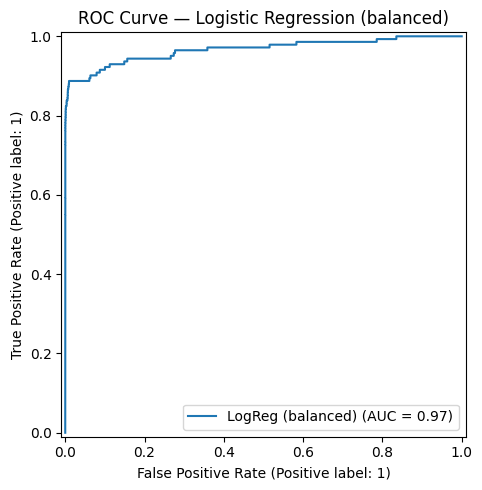

WindowsPath('../images/week3/roc_curve.png')

In [13]:
# -------------------- ROC Curve (matplotlib only) --------------------

# Δημιουργούμε figure & axis για το plot.
# figsize=(6, 5) -> ορίζει μέγεθος εικόνας (πλάτος, ύψος σε ίντσες).
fig_roc, ax_roc = plt.subplots(figsize=(6, 5))

# RocCurveDisplay: helper από sklearn που φτιάχνει καμπύλη ROC με μία γραμμή.
# - from_predictions: χρησιμοποιεί τις πραγματικές τιμές (y_test) και τις πιθανότητες (y_proba).
# - name="LogReg (balanced)": label που εμφανίζεται στο legend.
# - ax=ax_roc: σχεδιάζει στο συγκεκριμένο axis.
RocCurveDisplay.from_predictions(y_test, y_proba, name="LogReg (balanced)", ax=ax_roc)

# Προσθήκη τίτλου για καθαρή παρουσίαση
ax_roc.set_title("ROC Curve — Logistic Regression (balanced)")

# tight_layout(): αποφεύγει να “κοπούν” labels/titles στα άκρα της εικόνας
fig_roc.tight_layout()

# Ορίζουμε το path αποθήκευσης στον φάκελο images/week3/
roc_path = IMAGES_DIR / "roc_curve.png"

# Αποθήκευση εικόνας σε PNG:
# - dpi=150 -> καλή ανάλυση για report/GitHub
# - bbox_inches="tight" -> κόβει τα περιθώρια γύρω από το plot
fig_roc.savefig(roc_path, dpi=150, bbox_inches="tight")

# Εμφάνιση του plot στο notebook
plt.show()

# Εμφανίζει το path (σε Jupyter είναι clickable link)
roc_path



Τι είναι η καμπύλη ROC
- ROC = Receiver Operating Characteristic.
- Δείχνει το True Positive Rate (recall) vs False Positive Rate για όλα τα πιθανά thresholds.
- Η διαγώνιος = τυχαία πρόβλεψη. Όσο πιο μακριά από τη διαγώνιο, τόσο καλύτερο το μοντέλο.
- Το AUC (Area Under Curve) δίνει συνολικό σκορ (0.5 = random, 1.0 = τέλειο).

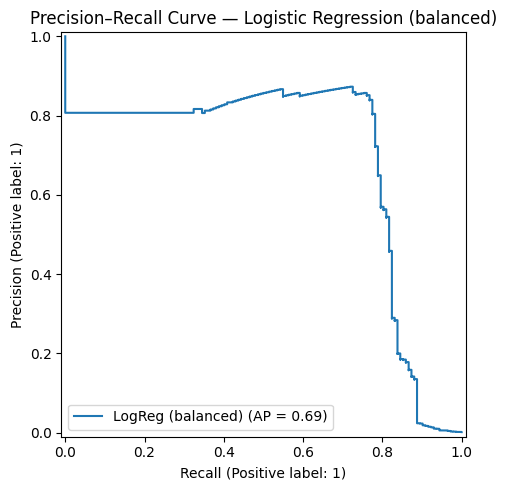

WindowsPath('../images/week3/pr_curve.png')

In [14]:

# -------------------- Precision–Recall Curve (matplotlib only) --------------------

# Δημιουργία figure & axis για το plot
fig_pr, ax_pr = plt.subplots(figsize=(6, 5))

# PrecisionRecallDisplay: helper από sklearn για την καμπύλη Precision–Recall.
# - from_predictions: χρησιμοποιεί τις πραγματικές τιμές (y_test) και τις πιθανότητες (y_proba).
# - name="LogReg (balanced)": label για το legend.
# - ax=ax_pr: σχεδιάζει στο συγκεκριμένο axis.
PrecisionRecallDisplay.from_predictions(y_test, y_proba, name="LogReg (balanced)", ax=ax_pr)

# Προσθήκη τίτλου για καλύτερη αναγνωσιμότητα
ax_pr.set_title("Precision–Recall Curve — Logistic Regression (balanced)")

# tight_layout: εξασφαλίζει ότι τίτλοι/labels δεν θα κοπούν
fig_pr.tight_layout()

# Αποθήκευση στο φάκελο images/week3/ με όνομα pr_curve.png
pr_path = IMAGES_DIR / "pr_curve.png"
fig_pr.savefig(pr_path, dpi=150, bbox_inches="tight")

# Εμφάνιση στο notebook
plt.show()

# Επιστροφή του path (σε Jupyter clickable link)
pr_path


🔎 Τι δείχνει η καμπύλη Precision–Recall

- Precision: από όσα προβλέψαμε ως fraud, πόσα ήταν όντως fraud.
- Recall: από όλα τα πραγματικά fraud, πόσα τα βρήκαμε.
- Η καμπύλη δείχνει τον συμβιβασμό μεταξύ τους για όλα τα thresholds.
- Στα imbalanced datasets, η PR curve είναι πιο κατατοπιστική από την ROC, γιατί η ROC μπορεί να φαίνεται καλή (υψηλό AUC) ακόμα κι όταν το precision είναι χαμηλό.

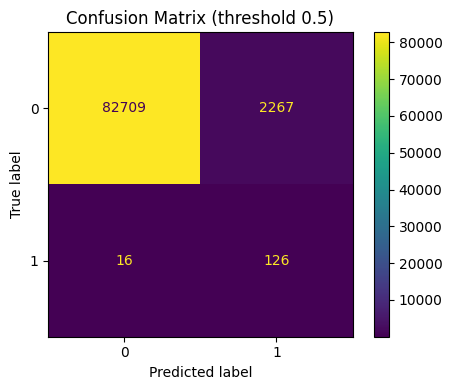

WindowsPath('../images/week3/confusion_matrix.png')

In [15]:
# -------------------- Confusion Matrix at default threshold 0.5 --------------------

# Δημιουργούμε figure & axis για το plot (λίγο πιο μικρό μέγεθος εδώ).
fig_cm, ax_cm = plt.subplots(figsize=(5, 4))

# ConfusionMatrixDisplay: helper από sklearn που φτιάχνει confusion matrix με μία γραμμή.
# - from_predictions: χρησιμοποιεί τις πραγματικές τιμές (y_test) και τις προβλέψεις (y_pred).
# - ax=ax_cm: σχεδιάζει στο συγκεκριμένο axis.
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax_cm)

# Προσθέτουμε τίτλο για αναγνωσιμότητα
ax_cm.set_title("Confusion Matrix (threshold 0.5)")

# tight_layout: φροντίζει να μη χαθούν labels/αριθμοί από την εικόνα
fig_cm.tight_layout()

# Ορίζουμε διαδρομή αποθήκευσης στον φάκελο images/week3/
cm_path = IMAGES_DIR / "confusion_matrix.png"

# Αποθήκευση σε PNG με 150 dpi (καλή ποιότητα για report/GitHub).
fig_cm.savefig(cm_path, dpi=150, bbox_inches="tight")

# Εμφάνιση στο notebook
plt.show()

# Επιστρέφουμε το path (σε Jupyter γίνεται clickable link)
cm_path



Τι δείχνει το Confusion Matrix
- True Negatives (TN): Non-fraud προβλέφθηκαν σωστά ως non-fraud.
- False Positives (FP): Non-fraud προβλέφθηκαν λανθασμένα ως fraud (false alarms).
- False Negatives (FN): Fraud προβλέφθηκαν λανθασμένα ως non-fraud (χαμένα frauds).
- True Positives (TP): Fraud προβλέφθηκαν σωστά ως fraud.
👉 Για fraud detection, το πιο κρίσιμο είναι να μειώσεις τα FN (να μη χάσεις πολλά πραγματικά fraud), ακόμη κι αν αυξηθούν λίγο τα FP.


## Επόμενα βήματα (για αύριο)
- **Regularization strength (`C`) sweep** με GridSearch, κύριο metric: **PR-AUC**
- **Threshold tuning** πάνω στην καμπύλη Precision–Recall (maximize F1 ή στοχευμένο Recall)
- Αναφορά (report): σύγκριση ROC-AUC vs PR-AUC σε context **class imbalance**
